# Continuation of an equilibrium solution

2025-11-04. Continue an ODE equilibrium solution using BifurcationKit, compare to DNS

## 0. Preliminaries

In [1]:
using LinearAlgebra, Polynomials, Plots, DelimitedFiles, BenchmarkTools, Revise
import BifurcationKit as BK

using CloudAtlas

#display("text/html", "<style>.container { width:100% !important; }</style>")

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

sx, sy, sz, tx, tz = halfbox_symmetries()

pwd()

"c:\\Users\\cbalusek\\Desktop\\CloudAtlas\\notebooks"

## 1. Construct ODE model, find equilibrium solution.

This repeats some code from notebook `find-ode-eqb.ipynb`.

In [ ]:
plot()

In [9]:
α, γ = 1.0, 2.0                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 1,2,3  #1,2,3  #1,1,3                 # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb

model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 

@show m = length(model);            # dimension of ODE model

J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
m = length(model) = 27


Load initial guesses for EQ1 (lower branch) and EQ2 (upper branch) from
files. These are computed by projecting DNS solutions onto the basis, using channelflow. 

In [10]:
xguess = myreaddlm("data/xeq1projection-Re200-1-2-3-27d.asc") #data/xeq1projection-Re200-1-2-3-27d.asc

R = 200
#x = zeros(m)
@show norm(model.f(xguess, R)); #x, R

norm(model.f(xguess, R)) = 0.009524056134927641


Find the ODE representations of the lower and upper branch solutions.

In [11]:
fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

@time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

@show norm(fr(xeq1))/norm(xeq1);

  0.213591 seconds (84.66 k allocations: 5.187 MiB, 91.10% compilation time)
norm(fr(xeq1)) / norm(xeq1) = 2.695727431883903e-10


## 2. Continuation of eqbs with BifurcationKit



Compute bifurcation diagram from xeq1 solution.

In [12]:
display(xguess)
display(xeq1)

27-element Vector{Float64}:
  0.1057562233477614
 -0.053953381733575084
  0.3882673617361376
 -0.017271618528877614
 -0.013280389303813082
  0.011256311213268288
  0.01244439528778787
 -0.017975383550434907
  0.0028606406132429436
 -0.007062219235032701
  ⋮
 -0.023425228121848714
 -0.03197420527401155
 -0.017992034721883737
 -0.004642245352151625
  0.010572383149277687
  0.02348270359960592
 -0.007331722175024302
 -0.007994514969769193
 -0.0010385283210509282

27-element Vector{Float64}:
  0.14241593342533237
 -0.06165934549569542
  0.37161822261211724
 -0.01291491181907537
 -0.01908676698712169
  0.01395834480901678
  0.03410340309537847
 -0.02881869829795404
 -0.0012496835809342045
 -0.010225492492641602
  ⋮
 -0.04100960677190574
 -0.03979818697604734
 -0.03079316346808097
 -0.022322975732190012
  0.013597078401275687
  0.03787469491503421
 -0.016262754264748075
 -0.008294583880080982
 -0.0004031257204449711

In [13]:
shear(xeq1, model)

1.6460527034370958

In [14]:
myshear = x -> shear(x,model)
myshear(xeq1)

1.6460527034370958

(J, K, L, m, R) = (1, 2, 3, 27, 200)


┌ Error: Failure to converge with given tolerance = 1.0e-10.
│ Step = 190
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-7.
│ Stopping continuation at continuation step 190.
└ @ BifurcationKit C:\Users\cbalusek\.julia\packages\BifurcationKit\H9RbT\src\continuation\Contbase.jl:70


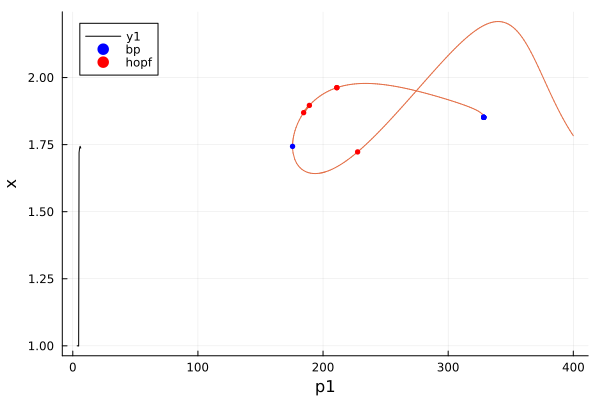

In [15]:
@show J, K, L, m, R

fp(x,p) = model.f(x,p[1])
prob1 = BK.BifurcationProblem(fp,
        xeq1,         # initial condition x0
        [Float64(R)], # set of parameters
        1;            # parameter index for continuation
        #record_from_solution = (x,p; k...) -> shear(x),
        plot_solution = (x,p; k...) -> myshear(x),
        record_from_solution = (x,p; k...) -> myshear(x),
    )

newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-07, dsmax=1.0, #Ask Gibson why dsmin was set to 1e-07
    max_steps = 200, newton_options = newtopts)

br1 = false
try
    br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)  #Ask Gibson what this does besides throw errors
    plot!(br1)
catch e
    println(e)
end


Compute bifurcation diagram from xeq2 solution. For some reason BifurcationKit doesn't go around the saddle-node bifurcation. I need to learn how to tune the algorithm.

Plot the ODE bifurcation diagram along with the DNS.

163.5222 : 175.6267708239224

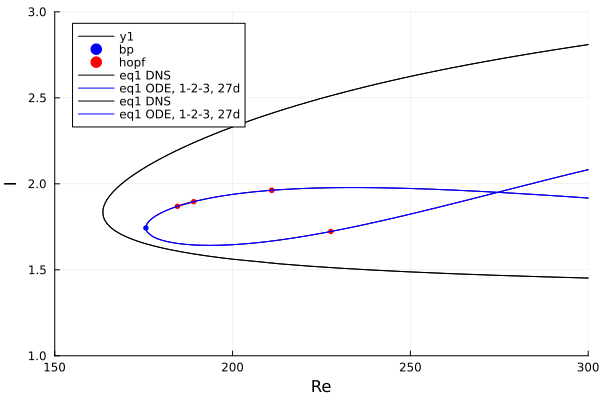

In [17]:
ReD1 = [br1.param br1.x];

eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
#@show minimum(eq1ReD[:,1]), minimum(ReD1[:,1])
print(minimum(eq1ReD[:,1]), " : ", minimum(ReD1[:,1]))
plot!(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, $J-$K-$L, $(m)d")
#plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))

In [2]:
minDNS = false
parameters = []
minimums = []
AYErrors = []
matrix = []
plotData = []

Any[]

In [2]:
function DataTable(a, y, r, n, c, fs)#, xg)#, na, ny)
    #vectorTable = []
    if (a >= 0.05 && y >= 0.05)
        α, γ = a, y                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
        J,K,L = 1,2,3  #1,2,3  #1,1,3      # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
        H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb
        

        try
            model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
            
            ###@show m = length(model);            # dimension of ODE model
            ##################
            #xguess = myreaddlm("data/xeq1projection-Re200-1-2-3-27d.asc") #data/xeq1projection-Re200-1-2-3-27d.asc
            ###xguess = xg

            R = r
            ###@show norm(model.f(xguess, R));
            ##################
            fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
            Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

            @time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)


            ###@show norm(fr(xeq1))/norm(xeq1);
            ##################
            shear(xeq1, model)
            ##################
            myshear = x -> shear(x,model)
            ####myshear(xeq1)
            I = myshear(xeq1)
            if I > 0 && I < 3
                if n > 0
                    push!(plotData, [sqrt((2*pi/α)^2 + (2*pi/γ)^2), I])
                else
                    pushfirst!(plotData, [sqrt((2*pi/α)^2 + (2*pi/γ)^2), I])
                end
            end
            ##################
            ###@show J, K, L, m, R

            fp(x,p) = model.f(x,p[1])
            prob1 = BK.BifurcationProblem(fp,
                xeq1,         # initial condition x0
                [Float64(R)], # set of parameters
                1;            # parameter index for continuation
                #record_from_solution = (x,p; k...) -> shear(x),
                plot_solution = (x,p; k...) -> myshear(x),
                record_from_solution = (x,p; k...) -> myshear(x),
            )

            newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
            contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
                max_steps = 600, newton_options = newtopts)
            ### contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-07, dsmax=1.0, 
            ###    max_steps = 200, newton_options = newtopts)

            br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)

            ##################
            ReD1 = [br1.param br1.x];

            plot!(ReD1[:,1], ReD1[:,2], color=c, label="", legendfontsize=fs)###"eq$n ODE, $J-$K-$L, $(m)d, $α x $γ", legendfontsize=fs)
            #display(ReD1)
            #plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
            plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))
            ##################
            if minimum(ReD1[:,1]) > 1
                if n > 0
                    push!(parameters, [α, γ])
                    push!(minimums, [minimum(ReD1[:,1])])
                else
                    pushfirst!(parameters, [α, γ])
                    pushfirst!(minimums, [minimum(ReD1[:,1])])
                end
                if n > 0
                    push!(matrix, vcat([r, α, γ, true], xeq1))
                else
                    pushfirst!(matrix, vcat([r, α, γ, true], xeq1))
                end
                global xguess = xeq1
            else
                #=
                if n > 0
                    push!(AYErrors, [r, α, γ, "minimum is 0"])
                else
                    pushfirst!(AYErrors, [r, α, γ, "minimum is 0"])
                end
                =#
                if n > 0
                    push!(matrix, vcat([r, α, γ, true], xeq1))
                else
                    pushfirst!(matrix, vcat([r, α, γ, true], xeq1))
                end
                global xguess = xeq1
            end
        catch e
            if n > 0
                push!(AYErrors, [r, α, γ, e])
                push!(matrix, vcat([r, α, γ, false], xguess))
            else
                pushfirst!(AYErrors, [r, α, γ, e])
                pushfirst!(matrix, vcat([r, α, γ, false], xguess))
            end
        end
    end
end

DataTable (generic function with 1 method)

In [3]:
using Suppressor

initialA, initialY = 1, 2
parameters = []
minimums = []
AYErrors = []
matrix = []
plotData = []
minDNS = 163.5222
numOfTests = 10
posiRangeOfChange = 1 #1.5
negRangeOfChange = 0 #0.85 #Do not set to 0
delta = (posiRangeOfChange + negRangeOfChange)/numOfTests
Re = 200 #This is supposed to be 200 you bone head
fontSize = 5
xguess = myreaddlm("data/xeq1projection-Re200-1-2-3-27d.asc")


@suppress begin
    eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
    plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS")

    numOfNegTests = round(negRangeOfChange/delta)
    negDelta = negRangeOfChange/numOfNegTests
    negToTotalRatio = numOfNegTests / numOfTests
    for i in 0:numOfNegTests
        DataTable(round(initialA - i * negDelta, digits = 8), round(initialY - 2 * i * negDelta, digits = 8), Re, -1, 
            RGBA(negToTotalRatio * i / numOfNegTests, 1 - negToTotalRatio * i / numOfNegTests, 0, 1), fontSize);
        ###display(RGBA(0 + j * (deltaY/rangeOfChangeInY)/2, 1 - j * (deltaY/rangeOfChangeInY)/2, 0, 1))
        #savefig("trash/α_$((initialA - rangeOfChangeInA) + i * deltaA).png")
    end
    
    matrix = matrix[1:length(matrix) - 1]
    plotData = plotData[1:length(plotData) - 1]
    global xguess = myreaddlm("data/xeq1projection-Re200-1-2-3-27d.asc")
    #push!(matrix, vcat([Re, initialA, initialY, true], xguess))

    numOfPosiTests = numOfTests - numOfNegTests
    posiDelta = posiRangeOfChange/numOfPosiTests
    for i in 0:numOfPosiTests
        DataTable(round(initialA + i * posiDelta, digits = 8), round(initialY + 2 * i * posiDelta, digits = 8), Re, 1,
            RGBA(negToTotalRatio + (1 - negToTotalRatio) * i / numOfPosiTests, (1 - negToTotalRatio) - (1 - negToTotalRatio) * i / numOfPosiTests, 0, 1), fontSize);
        ###display(RGBA(0 + j * (deltaY/rangeOfChangeInY)/2, 1 - j * (deltaY/rangeOfChangeInY)/2, 0, 1))
        #savefig("trash/α_$((initialA - rangeOfChangeInA) + i * deltaA).png")
    end

    
end

26-element Vector{Float64}:
   9.848957830857456e-5
  47.02151199010821
  11.755305829456983
   2.9396483457225364
   0.7340965065943932
   0.18411392804817314
   0.04522851123223119
   0.020798303720225092
   0.11106343405448134
   0.6955678628920935
   ⋮
   2.5352792543935356
 611.4935384260764
 152.88404087142032
  39.943024134259076
  10.110384616102948
   3.150101161485953
   1.8802972864702558
   0.6371385331907604
   1.1544095582281526

26-element Vector{Float64}:
  0.0003098359772101285
 11.77280304790184
  2.9408283161092355
  0.7372745766616938
  0.1847537472201552
  0.044258217223569256
  0.04386735592143718
  0.7633799674966936
  0.19700657173225475
  0.09687551293427618
  ⋮
  0.2872442231532982
  0.14941823202714224
 14.433628600440843
  3.5865210906240867
  0.8544128789383337
  0.7936515433726282
  0.3920101725759217
  2.202432249163767
  0.5539210767496825

26-element Vector{Float64}:
   0.0004948437618219111
 103.24977131211239
  25.812578962149782
   6.453664117450248
   1.623299775473845
   0.43611111639528155
   0.1157299684887039
   0.0880481457233437
   0.89766345019854
   0.24562619218305584
   ⋮
   1.561427968478866
   1.8526569188398714
   1.2699723110578731
 199.0550383165623
  48.98469726471681
  21.00206745411749
   5.34384317541651
   6.421996029486534
  13.937890735260481

26-element Vector{Float64}:
    0.0006539840724262829
 2121.6234593830136
  530.4058960237602
  132.60155058964963
   33.15054995527661
    8.288010641915681
    2.079004560436509
    0.5122399000906597
    0.12953114139807656
    0.040151061239897895
    ⋮
    0.10119094397859182
    0.04317720855163264
    0.15915157465063304
    2.770876742496144
    0.7061241017281723
    0.18238113385616944
    0.9478800490452944
    0.28456766746575185
    4.787540678047037

26-element Vector{Float64}:
   0.0007876621947393662
 290.90050114394535
  72.72532212468221
  18.180550118498452
   4.544632327158816
   1.1348567933204667
   0.6995628299773315
   0.1519680994088373
   0.07218025559409846
   0.02923359086999124
   ⋮
   0.8442526923478855
   0.20170556911708734
   0.3348016549593172
   1.1982185501384335
   0.2687437975511812
   0.23552756644265704
   1.284169843545652
   4.843464477723171
   1.8266257004630817

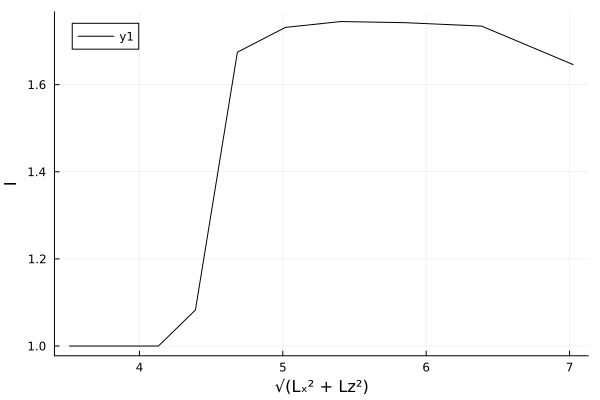

In [4]:
#show(getindex.(plotData,1))
#show(getindex.(plotData,2))
plot(getindex.(plotData,1),getindex.(plotData,2), color=:black, xlabel="√(Lₓ² + Lz²)", ylabel="I")

In [31]:
display(matrix)
display(AYErrors)
display(plotData)

11-element Vector{Any}:
 [200.0, 1.0, 2.0, 1.0, 0.14241593342533237, -0.06165934549569542, 0.37161822261211724, -0.01291491181907537, -0.01908676698712169, 0.01395834480901678  …  -0.00872351833490628, -0.04100960677190574, -0.03979818697604734, -0.03079316346808097, -0.022322975732190012, 0.013597078401275687, 0.03787469491503421, -0.016262754264748075, -0.008294583880080982, -0.0004031257204449711]
 [200.0, 1.1, 2.2, 0.0, 0.14241593342533237, -0.06165934549569542, 0.37161822261211724, -0.01291491181907537, -0.01908676698712169, 0.01395834480901678  …  -0.00872351833490628, -0.04100960677190574, -0.03979818697604734, -0.03079316346808097, -0.022322975732190012, 0.013597078401275687, 0.03787469491503421, -0.016262754264748075, -0.008294583880080982, -0.0004031257204449711]
 [200.0, 1.2, 2.4, 0.0, 0.14241593342533237, -0.06165934549569542, 0.37161822261211724, -0.01291491181907537, -0.01908676698712169, 0.01395834480901678  …  -0.00872351833490628, -0.04100960677190574, -0.0397981869760

5-element Vector{Any}:
 Any[200, 1.1, 2.2, "Stopping continuation."]
 Any[200, 1.2, 2.4, "Stopping continuation."]
 Any[200, 1.3, 2.6, "Stopping continuation."]
 Any[200, 1.4, 2.8, "Stopping continuation."]
 Any[200, 1.5, 3.0, "Stopping continuation."]

11-element Vector{Any}:
 [7.024814731040727, 1.6460527034370958]
 [6.386195210037023, 1.7344125280771534]
 [5.854012275867272, 1.742231690495946]
 [5.403703639262097, 1.7448427470684371]
 [5.017724807886233, 1.7313814720434335]
 [4.683209820693817, 1.6745482435563404]
 [4.390509206900454, 1.0827813243022446]
 [4.132243959435721, 1.0000000123531139]
 [3.9026748505781814, 1.0]
 [3.6972709110740665, 1.0]
 [3.5124073655203634, 1.0]

In [ ]:
display(parameters)
display(minimums)

In [ ]:
for i in 10:10:500
    contour((initialA - rangeOfChangeInA):deltaA:(initialA + rangeOfChangeInA), (initialY - rangeOfChangeInY):deltaY:(initialY + rangeOfChangeInY), matrix, xlabel="a", ylabel="y", lw=0, levels=i, fill = true)
    savefig("contour3/$(i)_levels.png")
end

In [ ]:
#contour((initialA - rangeOfChangeInA):deltaA:(initialA + rangeOfChangeInA), (initialY - rangeOfChangeInY):deltaY:(initialY + rangeOfChangeInY), matrix, xlabel="a", ylabel="y", lw=0, levels=2500, fill = true)
#savefig("contour2/2500_levels.png")

In [ ]:
matrix = zeros(2,2)
matrixMutate(1,1,1,matrix)
show(matrix)

In [ ]:
eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
plot!(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS")
plot!(xlabel="Re", ylabel="I", xlim=(70,300), ylim=(1,3.5))

In [ ]:
#savefig("testing/my_plot4.png")

In [ ]:
println("MinDNS : ", minDNS)
println("Parameters [α, γ] : ", parameters)
println("MinsOfODEs : ", minimums)
println("Error Parameters : ", AYErrors)
if length(minimums) != 0
    minIndex = findmin(minimums)[2]
    minValue = findmin(minimums)[1]
    println("Index Of Min Value : ", minIndex, ", Min Value : ", minValue, ", Parameters Of Min Value [α, γ] : [", parameters[minIndex][1], ", ", parameters[minIndex][2], "]")
end

In [ ]:
for i in 1:length(minimums)
    println("Data [α, γ], Min : ", parameters[i], ", ", minimums[i])
end

In [ ]:
display(plot!())
display(plot!())